In [1]:
import librosa

In [6]:
audio, sr = librosa.load(r"C:\Users\marko.vucic_ominimo\Desktop\music-classifier\data\musicnet\musicnet\train_data\1728.wav")

In [7]:
sr

22050

In [8]:
len(audio) / sr

251.14122448979592

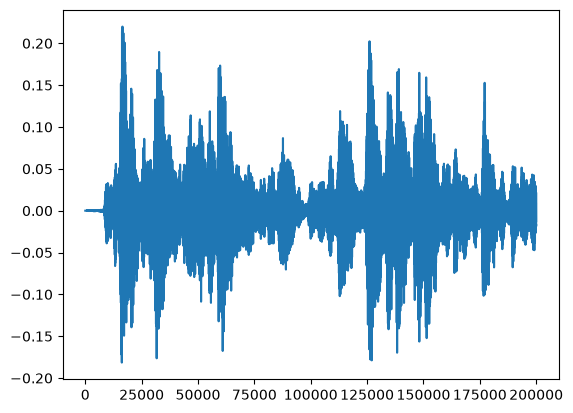

In [16]:
import matplotlib.pyplot as plt

N = 200000

plt.figure()
plt.plot(list(range(N)), audio[:N])
plt.show()


In [17]:
data = librosa.stft(audio)

In [22]:
data[200, 500]

np.complex64(-0.18131512-0.05846223j)

In [23]:
import numpy as np

np.abs(data)

array([[6.6886033e-04, 7.1498891e-03, 1.1155626e-02, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [7.7465182e-04, 8.4396414e-03, 3.4813799e-03, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.4805555e-03, 1.2290904e-02, 1.9428082e-02, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.4977435e-06, 7.3349429e-07, 1.5058561e-08, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.4909481e-06, 7.3694582e-07, 3.8239523e-09, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.4987793e-06, 7.3524149e-07, 3.5409251e-09, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], shape=(1025, 10816), dtype=float32)

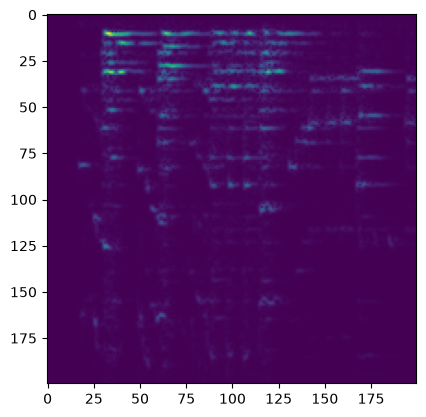

In [26]:
plt.imshow(np.abs(data[:200,:200]))

In [27]:
help(np.arange)

Help on built-in function arange in module numpy:

arange(
    start_or_stop,
    /,
    stop=None,
    step=1,
    *,
    dtype=None,
    device=None,
    like=None
)
    arange([start,] stop[, step,], dtype=None, *, device=None, like=None)

    Return evenly spaced values within a given interval.

    ``arange`` can be called with a varying number of positional arguments:

    * ``arange(stop)``: Values are generated within the half-open interval
      ``[0, stop)`` (in other words, the interval including `start` but
      excluding `stop`).
    * ``arange(start, stop)``: Values are generated within the half-open
      interval ``[start, stop)``.
    * ``arange(start, stop, step)`` Values are generated within the half-open
      interval ``[start, stop)``, with spacing between values given by
      ``step``.

    For integer arguments the function is roughly equivalent to the Python
    built-in :py:class:`range`, but returns an ndarray rather than a ``range``
    instance.

    When

In [41]:
signal = 20 * np.sin(2* np.pi * 440 * np.arange(0,stop=5,step=1/20000)) + 7 * np.sin(2* np.pi * 440 * 5/3 * np.arange(0,stop=5,step=1/20000))

In [42]:
signal.shape

(100000,)

In [43]:
stft = librosa.stft(signal)

In [44]:
stft.shape

(1025, 196)

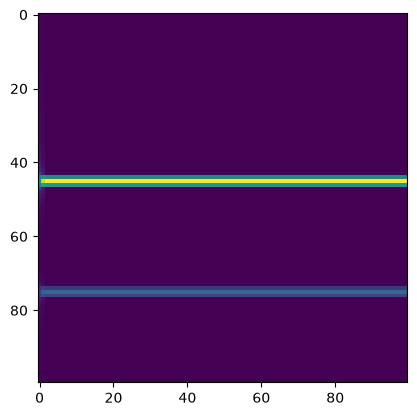

In [45]:
plt.imshow(np.abs(stft[:100,:100]))

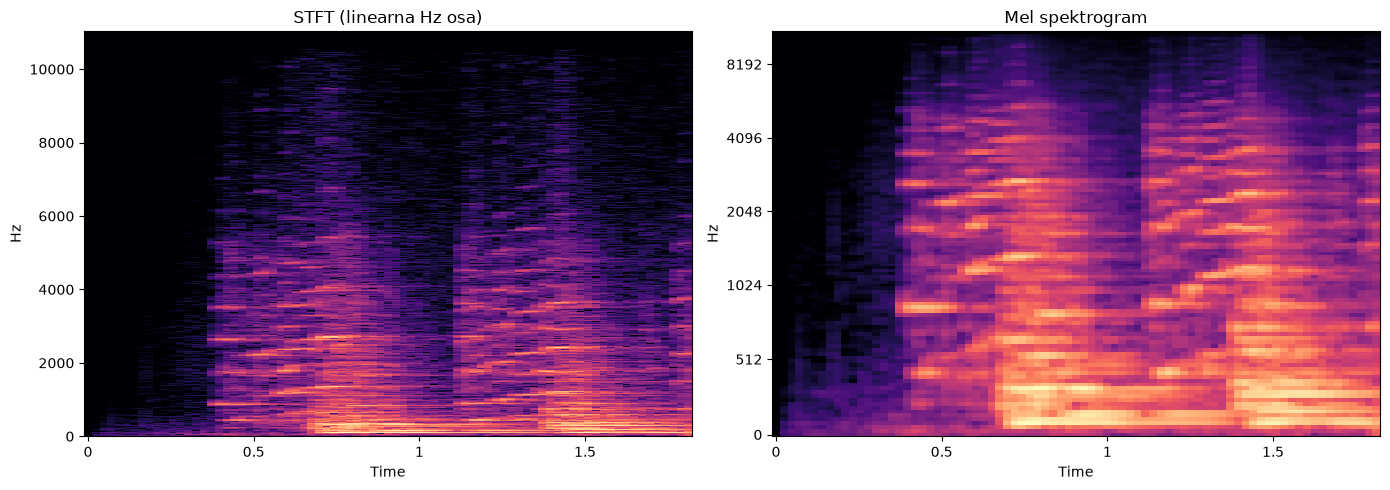

In [48]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# y, sr = librosa.load("data/musicnet/musicnet/train_data/1727.wav", sr=44100, duration=10.0)

stft = librosa.stft(audio[:40000], n_fft=2048, hop_length=512)
power = np.abs(stft) ** 2
power_db = librosa.power_to_db(power, ref=np.max)

mel = librosa.feature.melspectrogram(S=power, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

librosa.display.specshow(power_db, sr=sr, hop_length=512, x_axis="time", y_axis="hz", ax=ax[0])
ax[0].set_title("STFT (linearna Hz osa)")

librosa.display.specshow(mel_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=ax[1])
ax[1].set_title("Mel spektrogram")

plt.tight_layout()
plt.show()